# Where the memory goes when you train on 32 GPUs

Data parallelism does not run out of memory because the model is large. It runs out because
every GPU holds a bit-identical copy of optimizer state it will never independently use. ZeRO
is the observation that you can shard that copy and reassemble it only when needed — and that
for two of its three stages, doing so costs **no extra communication at all**.

This notebook builds 32 virtual GPUs out of CPU threads, gives each one a byte-accurate memory
ledger and a hand-written ring collective fabric, and trains a small transformer on top in four
modes: plain data parallelism, then ZeRO stages 1, 2 and 3. Then it measures what changed.

**The rule this notebook follows.** Every number below is either counted by a collective's own
byte counter and a memory arena, or derived from a formula printed next to it — and where both
exist they are asserted equal. Where a number is neither (communication *time*), it is labelled
a model and nothing depends on it.

**Runtime:** about 2 minutes on a CPU runtime. No GPU needed or used.

**What this does not prove** is set out in full near the end, before you are asked to believe
anything. The short version: threads are not GPUs, there is no network, and no claim is made
anywhere about speed.

In [1]:
# --- bootstrap: works on a fresh Colab runtime and locally, unchanged ---------
import os, sys, subprocess, time
T_START = time.time()

def _find_vzero():
    d = os.path.abspath(os.getcwd())
    for _ in range(4):
        if os.path.isdir(os.path.join(d, "vzero")):
            return d
        d = os.path.dirname(d)
    return None

root = _find_vzero()
if root is None:                      # Colab: fetch just this session's folder
    subprocess.run(["git", "clone", "--depth", "1", "--filter=blob:none", "--sparse",
                    "https://github.com/KarthikeyanMohanraj17/ERA_LLM_training.git",
                    "/content/ERA_LLM_training"], check=True)
    subprocess.run(["git", "sparse-checkout", "set", "session-12-distributed-training"],
                   cwd="/content/ERA_LLM_training", check=True)
    root = "/content/ERA_LLM_training/session-12-distributed-training"
sys.path.insert(0, root)
os.chdir(root)

for pkg in ("torch", "numpy", "matplotlib"):        # preinstalled on Colab
    try:
        __import__(pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

from vzero.env import configure
ENV = configure()
print(ENV.render())
print(f"  vzero at      {root}/vzero")

provenance
  python         3.12.13
  torch          2.14.0
  platform       macOS-26.6.2-arm64-arm-64bit (arm64)
  cpu_count      12
  colab          False
  vzero sha256   4682ea581ac35a99
  vzero at      /Users/karthikeyanmohanraj/Desktop/ERA/session_12/session-12-distributed-training/vzero


## 1. Why data parallelism hits a wall

Start with one concrete case and count bytes by hand.

GPT-2 XL has 1.5 billion parameters. Put it on one 16 GB card and train it with Adam in mixed
precision. What has to be resident?

- the fp16 weights you compute with — 2 bytes each — **3 GB**
- the fp16 gradients — **3 GB**
- an fp32 master copy of the weights, because fp16 updates lose too much precision — **6 GB**
- Adam's first moment `m`, fp32 — **6 GB**
- Adam's second moment `v`, fp32 — **6 GB**

That is **24 GB** before a single activation exists, on a 16 GB card. The paper puts it
plainly: *"a 1.5B parameter GPT-2 model requires 3GB of memory for its weights (or parameters)
in 16-bit precision, yet, it cannot be trained on a single GPU with 32GB memory."*

Now the part that makes ZeRO inevitable. Of those 24 GB, 18 GB is optimizer state, and it is
**identical on every rank** — every GPU computes the same averaged gradient and therefore the
same update. Adding a 33rd GPU does not shrink it by one byte. Data parallelism scales
throughput and does nothing at all for memory.

In [2]:
from vzero.analysis import REGIMES, STAGES, STAGE_NAMES, state_bytes_per_gpu, paper_table

print("bytes per parameter, by accounting regime\n")
print(f"{'regime':14}{'params':>9}{'grads':>8}{'optimizer':>11}{'total':>8}")
for name, (p, g, o) in REGIMES.items():
    print(f"{name:14}{p:>9}{g:>8}{o:>11}{p+g+o:>8}")
print("\nBoth come to 16 bytes per parameter -- which makes them look interchangeable.")
print("They are not, and the next cell is where that bites.")

bytes per parameter, by accounting regime

regime           params   grads  optimizer   total
fp32_adam             4       4          8      16
mixed_paper           2       2         12      16

Both come to 16 bytes per parameter -- which makes them look interchangeable.
They are not, and the next cell is where that bites.


Write it as a formula only now that the bytes are counted: for $\Psi$ parameters, training
costs $16\Psi$ bytes of model state per GPU. The paper writes this as $2\Psi + 2\Psi + K\Psi$
with $K = 12$ — two bytes of fp16 weights, two of fp16 gradients, and twelve of optimizer state.

**The trap.** My simulator runs in fp32 with Adam, which also comes to 16 bytes per parameter:
$4 + 4 + 8$. Same total, so it is tempting to treat the two regimes as the same thing. But ZeRO
stage 1 shards only the optimizer state, and that is $8/16$ of the total in fp32 against
$12/16$ in mixed precision. So the *same* ZeRO-1 saves 1.94× in one regime and 3.66× in the
other. My measured numbers are the weaker column, and I report them as such rather than
quoting the paper's.

In [3]:
N = 32
print(f"per-GPU model state at N={N}, as a multiple of Psi\n")
print(f"{'regime':14}" + "".join(f"{STAGE_NAMES[s]:>16}" for s in STAGES) + f"{'stage-1 saving':>16}")
for reg in REGIMES:
    v = [state_bytes_per_gpu(s, 1, N, reg) for s in STAGES]
    print(f"{reg:14}" + "".join(f"{x:>16.3f}" for x in v) + f"{v[0]/v[1]:>15.2f}x")

print("\n\ncheck the formulas against Table 1 of the ZeRO paper (arXiv:1910.02054), N=64\n")
print(f"{'Psi':>8}{'stage':>8}{'mine (GB)':>12}{'paper (GB)':>12}")
ok = True
for row in paper_table():
    for s in STAGES:
        mine, paper = row[f"stage{s}"], row[f"paper{s}"]
        ok &= abs(mine - paper) <= max(0.05, 0.01 * paper)
        print(f"{row['psi']/1e9:>7.1f}B{s:>8}{mine:>12.2f}{paper:>12.2f}")
assert ok, "formulas do not reproduce the paper"
print("\nevery published number reproduced.")

per-GPU model state at N=32, as a multiple of Psi

regime            ZeRO-0 (DDP)          ZeRO-1          ZeRO-2          ZeRO-3  stage-1 saving
fp32_adam               16.000           8.250           4.375           0.500           1.94x
mixed_paper             16.000           4.375           2.438           0.500           3.66x


check the formulas against Table 1 of the ZeRO paper (arXiv:1910.02054), N=64

     Psi   stage   mine (GB)  paper (GB)
    7.5B       0      120.00      120.00
    7.5B       1       31.41       31.40
    7.5B       2       16.64       16.60
    7.5B       3        1.88        1.88
  128.0B       0     2048.00     2048.00
  128.0B       1      536.00      536.00
  128.0B       2      284.00      284.00
  128.0B       3       32.00       32.00

every published number reproduced.


## 2. Thirty-two virtual GPUs

Each virtual GPU is a worker thread plus a memory arena that counts bytes. Threads rather than
processes for a concrete reason: 32 processes each importing torch costs 8–11 GB of RSS on this
machine, and per-rank memory would then have to be read out of noisy RSS instead of counted
exactly. Counting exactly is the whole point.

The arena has one rule that is easy to get wrong. Tensors are keyed by the address of their
underlying storage, so a `.view()` or `.narrow()` of something already counted adds **zero**
bytes. Counting `numel × itemsize` per tensor instead — the obvious implementation — silently
inflates every memory figure in the project, and no assertion downstream would notice, because
every mode would be inflated together.

The second rule is subtler and I got it wrong first time: the arena keeps a *strong reference*
to each counted storage. Without one, a storage gets freed, the allocator hands the same
address to the next tensor, and the arena decides it is "already counted" — undercounting from
then on. The test below is the one that caught it.

In [4]:
import gc, torch
from vzero.vgpu import MemArena, VGPUOutOfMemory

a = MemArena(rank=0)
t = a.alloc(1000, bucket="params", name="flat")
assert a.live_total == 4000
a.adopt(t.narrow(0, 0, 500), bucket="act", name="a_view")
assert a.live_total == 4000, f"a view was double-counted: {a.live_total}"
a.free(t); assert a.live_total == 0 and a.peak_total == 4000
print("views add zero bytes; peak is a watermark        OK")

b = MemArena(rank=1, capacity_bytes=4096)
b.alloc(1000, bucket="params", name="first")   # reference dropped on purpose
gc.collect()                                   # storage freed, address reusable
try:
    b.alloc(1000, bucket="params", name="second")
    print("FAIL: address reuse aliased a live record")
except VGPUOutOfMemory as e:
    print("address reuse cannot alias a live record       OK")
    print(f"  and a virtual GPU can run out of memory:\n  {e}")

views add zero bytes; peak is a watermark        OK
address reuse cannot alias a live record       OK
  and a virtual GPU can run out of memory:
  rank 1: allocating 4,000 B for params/'second' during phase 'init' would take live memory from 4,000 B to 8,000 B, over the 4,096 B capacity of this virtual GPU


## 3. The ring, on four ranks

Four ranks, each holding a different gradient for the same 4 numbers. Everyone needs the sum.

The naive approach sends everything to everyone: $N(N-1)$ messages, and the amount each rank
sends grows with $N$. The ring does better. Split the payload into $N$ chunks and go round in
two phases:

```
reduce-scatter   N-1 steps, each rank sends one chunk to its right neighbour,
                 which adds its own contribution. After N-1 steps rank r holds
                 the complete sum of chunk r, and nobody holds the whole thing.

all-gather       N-1 steps, each rank passes the chunk it owns around the ring
                 until everyone has all N chunks.
```

Each rank sends $(N-1)/N \cdot \Psi$ elements per phase, so $2(N-1)/N \cdot \Psi$ for the pair —
and that pair **is** an all-reduce. This matters more than it looks, and section 6 comes back
to it.

The detail that decides everything later: **the order of the additions is fixed by the
algorithm.** Chunk $c$ starts at rank $c+1$, is added to by each rank it passes through, and
rank $c$ adds its own contribution last. Float addition is not associative, so that order is
part of the answer, not an implementation detail.

In [5]:
# A standalone ring reduce-scatter, written out for four ranks so the order of
# additions is visible. The production fabric does exactly this; the cell after
# next checks the two agree bitwise.
import torch

def ring_reduce_scatter_trace(contribs):
    N = len(contribs)
    C = contribs[0].numel() // N
    work = [c.clone() for c in contribs]
    print(f"{'step':>5}  who sends which chunk to whom")
    for k in range(N - 1):
        moves, snap = [], [w.clone() for w in work]
        for r in range(N):
            idx = (r - 1 - k) % N
            moves.append(f"r{r}->r{(r+1)%N}:c{idx}")
            recv_idx = (r - 2 - k) % N
            work[r].narrow(0, recv_idx * C, C).add_(snap[(r - 1) % N].narrow(0, recv_idx * C, C))
        print(f"{k:>5}  " + "   ".join(moves))
    return [work[r].narrow(0, r * C, C).clone() for r in range(N)]

g = torch.Generator().manual_seed(0)
contribs = [torch.randn(4, generator=g) for _ in range(4)]
owned = ring_reduce_scatter_trace(contribs)

print(f"\nafter {4-1} steps each rank owns the full sum of its own chunk:")
for r in range(4):
    print(f"  rank {r} owns chunk {r} = {owned[r].item():+.6f}")
print(f"\nplain sum for comparison:      {[f'{v:+.6f}' for v in sum(contribs).tolist()]}")

from vzero.fabric import accumulation_order
print(f"\naddition order for each chunk (c+1, c+2, ..., c last):")
for c in range(4):
    print(f"  chunk {c}: " + " + ".join(f"contrib[{r}]" for r in accumulation_order(c, 4)))

 step  who sends which chunk to whom
    0  r0->r1:c3   r1->r2:c0   r2->r3:c1   r3->r0:c2
    1  r0->r1:c2   r1->r2:c3   r2->r3:c0   r3->r0:c1
    2  r0->r1:c1   r1->r2:c2   r2->r3:c3   r3->r0:c0

after 3 steps each rank owns the full sum of its own chunk:
  rank 0 owns chunk 0 = -1.119458
  rank 1 owns chunk 1 = -0.994764
  rank 2 owns chunk 2 = -3.443265
  rank 3 owns chunk 3 = +1.711195

plain sum for comparison:      ['-1.119458', '-0.994764', '-3.443265', '+1.711195']

addition order for each chunk (c+1, c+2, ..., c last):
  chunk 0: contrib[1] + contrib[2] + contrib[3] + contrib[0]
  chunk 1: contrib[2] + contrib[3] + contrib[0] + contrib[1]
  chunk 2: contrib[3] + contrib[0] + contrib[1] + contrib[2]
  chunk 3: contrib[0] + contrib[1] + contrib[2] + contrib[3]


In [6]:
# The production fabric, checked three ways at the real world size of 32.
from vzero.fabric import Fabric, ring_bytes
from vzero.pool import run_workers

W, P = 32, 32 * 16 * 3
src = [torch.randn(P, generator=torch.Generator().manual_seed(i)) for i in range(W)]

# (a) all_reduce is literally reduce_scatter + all_gather, bitwise
f1 = Fabric(W); ar = [s.clone() for s in src]
run_workers(W, lambda r: f1.all_reduce(r, ar[r], key="a", op="mean"), f1)
f2 = Fabric(W); sh = [torch.empty(P // W) for _ in range(W)]; full = [torch.empty(P) for _ in range(W)]
def rs_ag(r):
    f2.reduce_scatter(r, src[r].clone(), sh[r], key="rs", op="mean")
    f2.all_gather(r, sh[r], full[r], key="ag")
run_workers(W, rs_ag, f2)
assert all(torch.equal(ar[r], full[r]) for r in range(W))
print("all_reduce == reduce_scatter + all_gather, bitwise on all 32 ranks   OK")

# (b) the cheap path and a real 31-step ring agree on bits AND on bytes
res = {}
for impl in ("direct", "ring"):
    f = Fabric(W, impl=impl); s_ = [torch.empty(P // W) for _ in range(W)]; o_ = [torch.empty(P) for _ in range(W)]
    def work(r, f=f, s_=s_, o_=o_):
        f.reduce_scatter(r, src[r].clone(), s_[r], key="rs", op="mean")
        f.all_gather(r, s_[r], o_[r], key="ag")
    run_workers(W, work, f)
    res[impl] = (o_, f.totals()["per_rank_sent"])
assert all(torch.equal(res["direct"][0][r], res["ring"][0][r]) for r in range(W))
assert res["direct"][1] == res["ring"][1]
print("the fast path is bit- and byte-identical to a real 31-step ring       OK")

# (c) the byte counters equal the closed form exactly -- no slack
want = ring_bytes("reduce_scatter", P, W) + ring_bytes("all_gather", P, W)
assert want == ring_bytes("all_reduce", P, W)
assert all(f2.stats[r].bytes_sent == want for r in range(W))
print(f"byte counters == 2(N-1)/N x P x 4 = {want:,} B, exactly, every rank   OK")

all_reduce == reduce_scatter + all_gather, bitwise on all 32 ranks   OK


the fast path is bit- and byte-identical to a real 31-step ring       OK
byte counters == 2(N-1)/N x P x 4 = 11,904 B, exactly, every rank   OK


## 4. The model, and how it gets cut into 32 pieces

A small pre-LN decoder-only transformer: vocab 509, `d_model` 64, 4 heads, 4 layers, sequence
64, untied output head. $\Psi$ = 269,821 parameters. Three of those choices are deliberate.

**509 and 64 give a $\Psi$ that is not a multiple of 32.** The flat buffer genuinely needs
padding, and a test guards this — a tidier configuration would quietly delete the lesson.

**The head is not tied to the embedding.** A tied head is used twice in the forward pass, so a
post-accumulate gradient hook fires twice and would reduce-scatter a half-accumulated gradient.
Real FSDP handles that with an explicit accumulation counter; untying sidesteps it, and saying
so is more honest than pretending the problem does not exist.

**Sharding is per group, not per tensor and not one buffer for the whole model.** A group is a
unit we gather as a whole — the embeddings, each block, the final LayerNorm, the head. And all
four ZeRO modes use the *same* grouping. That is not cosmetic: the ring's addition order
depends on which chunk an element lands in, so changing the grouping changes the summation
order and the last bits. Identical grouping is what makes the bitwise claim in section 7
possible at all.

In [7]:
from vzero.model import PRESETS
cfg = PRESETS["xs"]
space = cfg.space(32)
r = space.report()
print(f"Psi = {r['psi']:,}   Psi mod 32 = {r['psi'] % 32}   -> padding is unavoidable\n")
print(space.table())
print(f"\nlargest group {r['max_group_numel']:,} elements -> that, not Psi/32, sets ZeRO-3's")
print(f"transient buffer. {r['n_straddling']}/{r['n_params']} parameters straddle a shard")
print(f"boundary (up to {r['max_pieces']} ranks): sharding is over bytes, not over layers.")
print(f"\nLook at ln_f: 128 real elements padded to 512. Seventy-five percent of that group is")
print(f"padding, because a 128-element LayerNorm does not divide 32 ways. This is why FSDP1")
print(f"flattens a wrapping unit into one FlatParameter and why DeepSpeed has")
print(f"stage3_param_persistence_threshold -- below some size, sharding costs more than it saves.")

Psi = 269,821   Psi mod 32 = 29   -> padding is unavoidable



group            raw    padded    shard    pad    pad%
embed         36,672    36,864    1,152    192   0.52%
block0        49,984    50,176    1,568    192   0.38%
block1        49,984    50,176    1,568    192   0.38%
block2        49,984    50,176    1,568    192   0.38%
block3        49,984    50,176    1,568    192   0.38%
ln_f             128       512       16    384  75.00%
head          33,085    33,280    1,040    195   0.59%
TOTAL        269,821   271,360    8,480  1,539   0.57%

largest group 50,176 elements -> that, not Psi/32, sets ZeRO-3's
transient buffer. 25/54 parameters straddle a shard
boundary (up to 32 ranks): sharding is over bytes, not over layers.

Look at ln_f: 128 real elements padded to 512. Seventy-five percent of that group is
padding, because a 128-element LayerNorm does not divide 32 ways. This is why FSDP1
flattens a wrapping unit into one FlatParameter and why DeepSpeed has
stage3_param_persistence_threshold -- below some size, sharding costs more tha

## 5. The four modes

What differs between them is exactly three things — where parameters live, where gradients
live, and where optimizer state lives.

| | parameters | gradients | optimizer | collectives per step |
|---|---|---|---|---|
| **ZeRO-0 (DDP)** | full | full | full | `all_reduce(grads)` |
| **ZeRO-1** | full | full | **shard** | `reduce_scatter(grads)`, `all_gather(params)` |
| **ZeRO-2** | full | **shard** | **shard** | same two, but each group's gradient is freed the moment it is reduced |
| **ZeRO-3** | **shard** | **shard** | **shard** | `all_gather(params)` in forward, again in backward, `reduce_scatter(grads)` |

ZeRO-1 and ZeRO-2 run the *same collectives on the same payloads*. The only difference is
gradient residency: ZeRO-1 keeps a full gradient buffer alive because nothing forces it not to,
ZeRO-2 reduce-scatters each group's gradient as soon as it is complete and frees it. So the
memory figure has to show that difference as a measurement, not a relabelling.

ZeRO-3 has one genuinely hard problem. Autograd **saves the weight tensor** for backward, so
dropping your reference to a gathered buffer does not free it. Real FSDP solves this by
resizing the underlying storage to zero bytes after forward and resizing it back before
backward needs it — saved views follow the storage. That is what the code below does, and it is
why ZeRO-3 can use ordinary `F.linear` / `F.embedding` / `F.layer_norm` rather than
hand-written backward passes. Which in turn is why it comes out bitwise identical to the other
three modes instead of merely close.

The code printed below is the code that produced every number in this notebook — read out of
the module with `inspect.getsource`, not retyped.

In [8]:
import inspect
from vzero.engine import GroupState, Worker

for fn in (Worker._finish_ddp, Worker._finish_zero1, Worker._finish_sharded,
           Worker._install_grad_hooks):
    print(inspect.getsource(fn))

    def _finish_ddp(self) -> None:
        """Every rank all-reduces the whole gradient and performs the identical
        Adam update. 32 ranks doing the same arithmetic 32 times."""
        for gid, gs in self.groups.items():
            pad = gs.padded - self.space.groups[gid].raw_numel
            if self.rc.ablation != "no_reduce":
                self.fab.all_reduce(self.rank, gs.full.grad, key=f"ar/{gid}",
                                    op=self._op(), pad_numel=pad)
            self.arena.note_phase("opt")
            gs.opt.step(gs.full_d, gs.full.grad)
            gs.full.grad.zero_()

    def _finish_zero1(self) -> None:
        """Gradients stay fully resident; only the optimizer state is sharded."""
        for gid, gs in self.groups.items():
            pad = gs.padded - self.space.groups[gid].raw_numel
            if self.rc.zero1_naive:
                # The footgun: all_reduce then take a slice. Correct loss, same
                # memory as the efficient version, 

In [9]:
print(inspect.getsource(GroupState.materialise))
print(inspect.getsource(GroupState.reshard))

    def materialise(self, fab: Fabric, tag: str) -> None:
        """all_gather this group's parameters into a live buffer.

        The write has to happen without bumping the version counter. Autograd
        saved views of this exact storage during forward and records the version
        it saw; re-gathering into it in backward would look like "a variable
        needed for gradient computation was modified in place" and raise. The
        escape hatch is the one real FSDP2 uses at its own all-gather copy-out --
        see torch/distributed/fsdp/_fully_shard/_fsdp_collectives.py, which wraps
        the same operation in the same context manager.
        """
        if self.gathered:
            return
        with torch.autograd._unsafe_preserve_version_counter(self.full_d):
            self.full_d.untyped_storage().resize_(self._nbytes)
            self.arena.adopt(self.full_d, bucket="transient", name=f"{self.gid}.gathered")
            fab.all_gather(self.rank, self.shard, self

## 6. Run all four

Same model, same seeds, same data, 32 virtual GPUs. Only the sharding changes.

In [10]:
import time
from vzero.engine import RunConfig, run, Reference

STEPS = 12
runs, timings = {}, {}
for m in STAGES:
    t = time.perf_counter()
    runs[m] = run(cfg, RunConfig(mode=m, world=32, steps=STEPS))
    timings[m] = time.perf_counter() - t
    print(f"  ZeRO-{m} done in {timings[m]:5.1f}s")

ref = Reference(cfg, RunConfig(world=32, steps=STEPS), order="ring").run()
naive = run(cfg, RunConfig(mode=1, world=32, steps=STEPS, zero1_naive=True))
per_step = {m: runs[m].comm["per_rank_sent"][0] // STEPS for m in STAGES}
print(f"\nloss fell {runs[0].losses_mean[0]:.4f} -> {runs[0].losses_mean[-1]:.4f}"
      f"   (uniform would be ln(509) = {__import__('math').log(cfg.vocab):.4f})")

  ZeRO-0 done in   6.2s


  ZeRO-1 done in   7.3s


  ZeRO-2 done in   7.3s


  ZeRO-3 done in  10.3s



loss fell 6.6959 -> 6.3354   (uniform would be ln(509) = 6.2324)


In [11]:
MB = 1 << 20
b0 = runs[0].peak_breakdown[0]
st0 = sum(b0[k] for k in ("params", "grads", "opt"))
p0 = runs[0].peak_total[0]
print(f"{'mode':16}{'state/rank':>12}{'vs DDP':>9}{'peak/rank':>12}{'vs DDP':>9}"
      f"{'comm/step':>12}{'vs DDP':>9}{'collectives':>12}")
for m in STAGES:
    b = runs[m].peak_breakdown[0]
    st = sum(b[k] for k in ("params", "grads", "opt"))
    pk = runs[m].peak_total[0]
    print(f"{STAGE_NAMES[m]:16}{st/MB:>11.3f}M{st0/st:>8.2f}x{pk/MB:>11.3f}M{p0/pk:>8.2f}x"
          f"{per_step[m]/MB:>11.3f}M{per_step[m]/per_step[0]:>8.4f}x"
          f"{runs[m].comm['per_rank_n'][0]//STEPS:>12}")

print(f"\nThree things to read off this table.")
print(f"  1. ZeRO-3 shards model state by exactly {st0/sum(runs[3].peak_breakdown[0][k] for k in ('params','grads','opt')):.2f}x -- the theoretical 32x, measured.")
print(f"  2. ZeRO-1 and ZeRO-2 send {per_step[0]:,} B/rank/step. So does DDP. To the byte.")
print(f"  3. ZeRO-3 sends {per_step[3]/per_step[0]:.4f}x DDP. Not approximately.")
print(f"\nAnd the one that is easy to miss: the peak column falls far less than the state")
print(f"column ({p0/runs[3].peak_total[0]:.2f}x against {st0/sum(runs[3].peak_breakdown[0][k] for k in ('params','grads','opt')):.2f}x). The next figure says why.")

mode              state/rank   vs DDP   peak/rank   vs DDP   comm/step   vs DDP collectives
ZeRO-0 (DDP)          4.141M    1.00x      5.567M    1.00x      2.006M  1.0000x          14
ZeRO-1                2.167M    1.91x      3.594M    1.55x      2.006M  1.0000x          14
ZeRO-2                1.132M    3.66x      2.558M    2.18x      2.006M  1.0000x          14
ZeRO-3                0.129M   32.00x      1.670M    3.33x      3.008M  1.5000x          21

Three things to read off this table.
  1. ZeRO-3 shards model state by exactly 32.00x -- the theoretical 32x, measured.
  2. ZeRO-1 and ZeRO-2 send 2,103,040 B/rank/step. So does DDP. To the byte.
  3. ZeRO-3 sends 1.5000x DDP. Not approximately.

And the one that is easy to miss: the peak column falls far less than the state
column (3.33x against 32.00x). The next figure says why.


### What actually shrinks

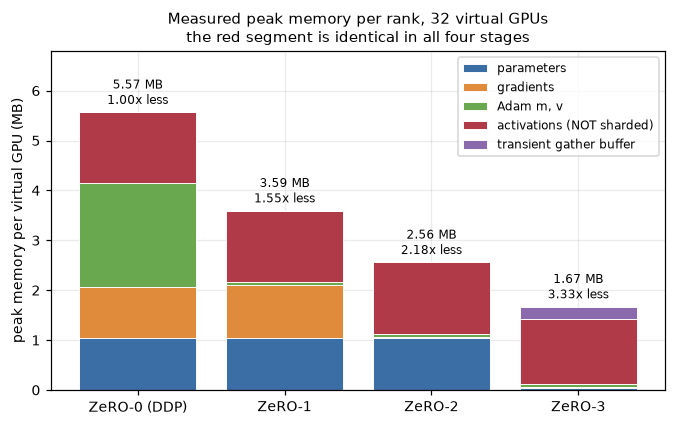

In [12]:
from vzero import report
from IPython.display import Image, display
import os
os.makedirs("figures", exist_ok=True)
display(Image(report.fig_memory_breakdown(runs, "figures/01-memory-breakdown.png")))

Each stage removes exactly the component it claims to: Adam's `m` and `v` at stage 1,
gradients at stage 2, parameters at stage 3.

The red segment does not move. **Activations do not shard under any ZeRO stage** — ZeRO
partitions model state, and activations are not model state. They are
$O(\text{batch} \times \text{seq} \times d \times L)$ per rank and they stay exactly where they
were. On this small model they are most of ZeRO-3's remaining bar, which is why a 32× reduction
in model state shows up as a much smaller reduction in peak memory.

That is not a flaw in the simulation, it is the actual situation, and it is why activation
checkpointing is not optional at scale. It is a different axis, and it is not ZeRO.

The assertion suite checks this rather than leaving it to the eye: activation bytes are
*identical* across all four modes, and identical across all 32 ranks.

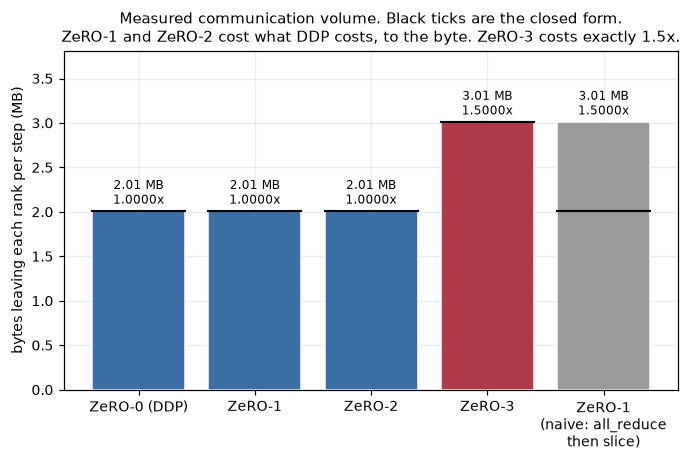

In [13]:
display(Image(report.fig_comm_volume(per_step, naive.comm["per_rank_sent"][0] // STEPS,
                                     space.psi_padded, 32, "figures/03-comm-volume.png")))

## 7. Why ZeRO-1 and ZeRO-2 cost exactly what DDP costs

This is the single most misunderstood thing about ZeRO, so here it is slowly.

The wrong intuition is easy to have: DDP does one collective, ZeRO-1 does two, so ZeRO-1 must
cost more. I believed it until I counted.

A ring all-reduce is *already* two collectives. It is a reduce-scatter followed by an
all-gather — that is not an approximation of how it works, it is how it works. Each phase moves
$(N-1)/N \cdot \Psi$ elements per rank, so an all-reduce moves $2(N-1)/N \cdot \Psi$.

ZeRO-1 also does two phases and also moves $2(N-1)/N \cdot \Psi$. Nothing was added. What
changed is *what the all-gather carries*: DDP's all-gather carries reduced gradients back to
everyone, ZeRO-1's carries updated parameters. Same element count, different tensor. The
optimizer step simply moved to sit between the two phases instead of after both.

ZeRO-2 changes neither collective. It only frees the gradient earlier. Free.

ZeRO-3 adds a genuine third phase, because the parameters gathered for the forward pass were
released and have to be gathered again for backward: $3(N-1)/N \cdot \Psi$, which is exactly
1.5× — for every $N$, not just for 32.

The bar chart above is the receipt: three bars at exactly the same height, one at exactly 1.5×,
each with the closed form drawn on it as a black tick.

**The grey bar is the part I would have got wrong.** ZeRO-1 does not have to be written
efficiently. The tempting implementation is "all-reduce the gradients, then have each rank
update its own shard, then all-gather the parameters" — which is correct, produces a *bitwise
identical* model, uses the same memory, and costs 1.5× DDP for nothing. A correct loss curve
would never have told me.

## 8. Are these four actually the same training run?

Everything above is worthless if the four modes are not computing the same thing. The usual
check — plot the loss curves and see that they overlap — is far weaker than it looks, and
section 9 shows four broken implementations whose loss also falls.

So this project aims higher than "close". **All four modes are asserted to be bitwise
identical**, to each other and to a single-rank reference. That is possible because of two
design decisions made earlier for exactly this reason:

- `all_reduce` is built as reduce-scatter plus all-gather, so the gradient ZeRO-0 sees is the
  *same additions in the same order* as the shard ZeRO-1/2/3 see; the all-gather adds no
  arithmetic.
- Adam is element-wise, so running it on a shard gives bitwise what running it on the whole
  tensor gives for those indices.

The reference accumulates the same 32 microbatch gradients in that same ring order. A second
reference accumulates them in plain rank order instead — that one is genuinely independent, and
the difference between the two measures how much float drift the reordering causes. That is the
only thing a tolerance is needed for anywhere in this project.

In [14]:
from vzero.validate import validate
rep = validate(cfg, world=32, steps=4)
print(rep.render())
assert rep.all_passed

  [PASS] psi not divisible by world                               Psi=269,821, Psi mod 32 = 29 -> padding is real
  [PASS] shards tile the padded space                             32 x 8,480 = 271,360
  [PASS] reference actually learns                                loss 6.6959 -> 6.5982 (fell 0.0977; ln(vocab)=6.232)
  [PASS] ZeRO-0 == ZeRO-1 bitwise                                 max|delta|=0.000e+00, 0/54 tensors differ
  [PASS] ZeRO-0 == ZeRO-2 bitwise                                 max|delta|=0.000e+00, 0/54 tensors differ
  [PASS] ZeRO-0 == ZeRO-3 bitwise                                 max|delta|=0.000e+00, 0/54 tensors differ
  [PASS] ZeRO-0 == ring-order reference bitwise                   max|delta|=0.000e+00, 0/54 tensors differ
  [PASS] ZeRO-0 loss == reference bitwise                         max|dLoss|=0.000e+00
  [PASS] ZeRO-1 == ring-order reference bitwise                   max|delta|=0.000e+00, 0/54 tensors differ
  [PASS] ZeRO-1 loss == reference bitwise            

## 9. Four deliberate bugs

An assertion that has never failed is not evidence that it can. Each of these breaks the
implementation in a way someone would plausibly ship:

- **`no_reduce`** — never reduce the gradients across ranks
- **`shard_offset`** — each rank's optimizer updates a slice one element off from the one it owns
- **`no_all_gather`** — never reassemble the parameters after the optimizer step
- **`sum_not_mean`** — reduce with sum instead of mean; forget the $1/N$

In [15]:
from vzero.engine import RunConfig, run
ABL = ("no_reduce", "shard_offset", "no_all_gather", "sum_not_mean")
abl = {a: run(cfg, RunConfig(mode=2, world=32, steps=STEPS, ablation=a)) for a in ABL}
good = max(abs(x - y) for x, y in zip(runs[2].losses_mean, ref["losses"]))
print(f"{'variant':16}{'max|dLoss|':>13}  {'loss start -> end':>24}   caught by")
print(f"{'correct ZeRO-2':16}{good:>13.3e}  {runs[2].losses_mean[0]:>10.4f} ->{runs[2].losses_mean[-1]:>9.4f}   --")
for a, r in abl.items():
    d = max(abs(x - y) for x, y in zip(r.losses_mean, ref["losses"]))
    fell = "(loss still fell)" if r.losses_mean[-1] < r.losses_mean[0] else ""
    by = "a 1e-4 tolerance" if d > 1e-4 else "ONLY the bitwise check"
    print(f"{a:16}{d:>13.3e}  {r.losses_mean[0]:>10.4f} ->{r.losses_mean[-1]:>9.4f}   {by} {fell}")

variant            max|dLoss|         loss start -> end   caught by
correct ZeRO-2      0.000e+00      6.6959 ->   6.3354   --
no_reduce           2.696e-01      6.6959 ->   6.6011   a 1e-4 tolerance (loss still fell)
shard_offset        2.455e-01      6.6959 ->   6.4996   a 1e-4 tolerance (loss still fell)
no_all_gather       4.021e-01      6.6959 ->   6.6778   a 1e-4 tolerance (loss still fell)
sum_not_mean        6.512e-06      6.6959 ->   6.3354   ONLY the bitwise check (loss still fell)


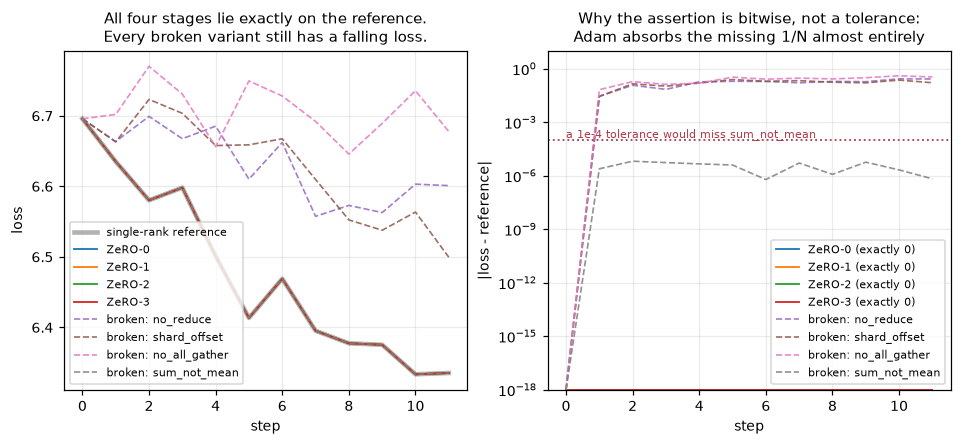

In [16]:
display(Image(report.fig_loss_and_ablations(runs, ref["losses"], abl,
                                            "figures/05-loss-and-ablations.png")))

**Every one of the four broken variants still has a falling loss.** "It trains" is not evidence
of anything.

`sum_not_mean` is the interesting one. Forgetting to divide by $N$ makes every gradient 32×
too large, which under SGD would be a 32× learning rate and an immediate blow-up. Under Adam it
is almost invisible: the update is $\mathrm{lr}\cdot m/(\sqrt{v}+\epsilon)$, and scaling $g$ by
32 scales both $m$ and $\sqrt{v}$ by 32, so the ratio barely moves. The only trace is
$\epsilon$ becoming effectively $\epsilon/32$. It shifts the loss by about $10^{-5}$.

Any tolerance loose enough to survive honest float drift would wave that bug straight through.
The bitwise assertion catches it. That is the argument for building the fabric so bitwise
equality is achievable in the first place — it was not tidiness, it bought real discriminating
power.

## 10. Scaling: what changes with N, and what does not

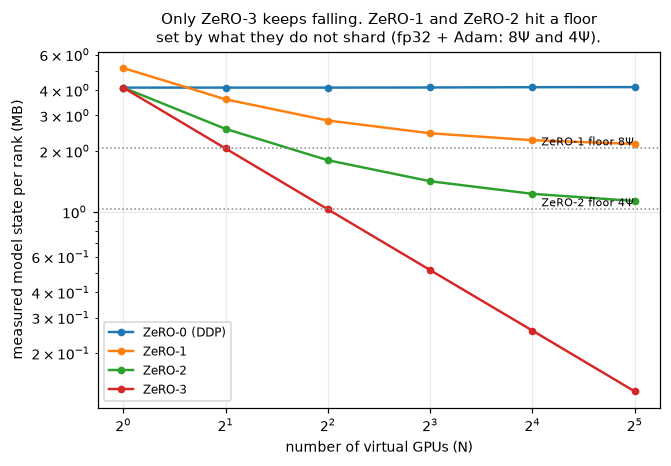

In [17]:
sweep, pad_vs_n, psi_pad_of = {}, {}, {}
for w in (1, 2, 4, 8, 16, 32):
    sp = cfg.space(w)
    psi_pad_of[w], pad_vs_n[w] = sp.psi_padded, sp.report()["pad_frac"]
    sweep[w] = {}
    for m in STAGES:
        b = run(cfg, RunConfig(mode=m, world=w, steps=2)).peak_breakdown[0]
        sweep[w][m] = sum(b[k] for k in ("params", "grads", "opt"))
display(Image(report.fig_memory_vs_world(sweep, psi_pad_of, "figures/04-memory-vs-N.png")))

ZeRO-1 and ZeRO-2 flatten out. They have a floor set by what they do not shard — $8\Psi$ and
$4\Psi$ in fp32 with Adam — and no amount of extra GPUs gets below it. Only ZeRO-3 has no
floor, because it shards all three components.

That is the real argument for stage 3, and it is a statement about asymptotes rather than about
any particular $N$.

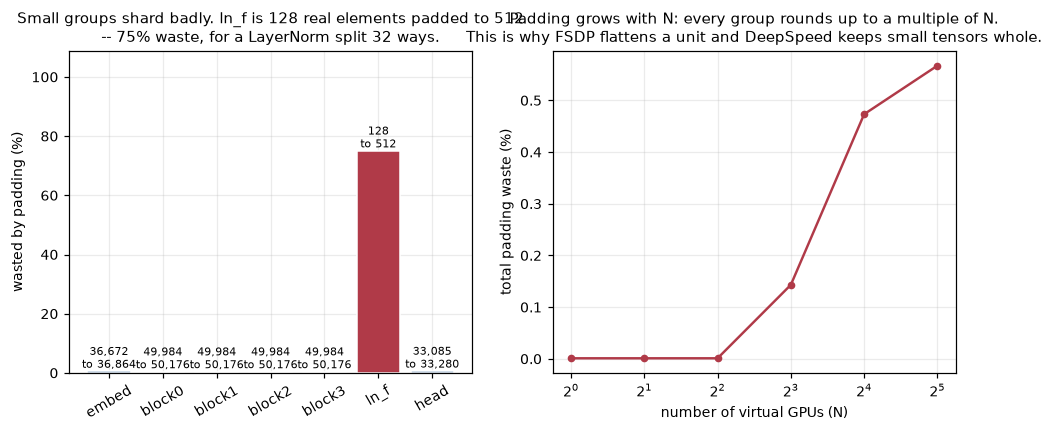

In [18]:
display(Image(report.fig_padding(space.report(), pad_vs_n, "figures/06-padding.png")))

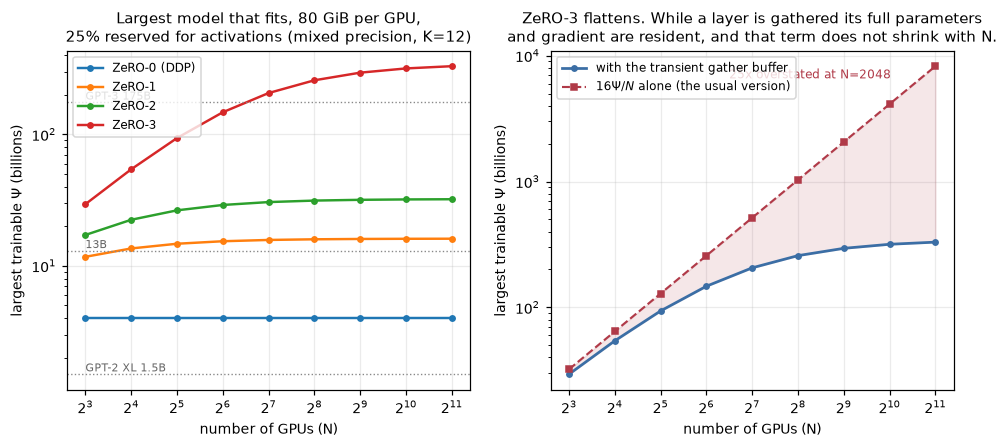

largest trainable Psi, 80 GiB per GPU, 25% reserved for activations,
mixed precision (K=12), 32 layers

     N      ZeRO-0 (DDP)            ZeRO-1            ZeRO-2            ZeRO-3
     8              4.0B             11.7B             17.2B             29.5B
    32              4.0B             14.7B             26.4B             93.7B
    64              4.0B             15.4B             29.0B            147.3B
   512              4.0B             16.0B             31.8B            294.5B

ZeRO-3's transient gather buffer is why that last column stops growing:
     N       with it     ignoring it   overstated by
    32         93.7B          128.8B              1x
   128        206.2B          515.4B              2x
   512        294.5B         2061.6B              7x
  2048        329.9B         8246.3B             25x


In [19]:
from vzero.analysis import GiB, max_psi
display(Image(report.fig_scaling("figures/07-scaling.png")))

print("largest trainable Psi, 80 GiB per GPU, 25% reserved for activations,")
print("mixed precision (K=12), 32 layers\n")
print(f"{'N':>6}" + "".join(f"{STAGE_NAMES[s]:>18}" for s in STAGES))
for w in (8, 32, 64, 512):
    print(f"{w:>6}" + "".join(
        f"{max_psi(s, 80*GiB, w, regime='mixed_paper', n_layers=32)/1e9:>17.1f}B" for s in STAGES))

print("\nZeRO-3's transient gather buffer is why that last column stops growing:")
print(f"{'N':>6}{'with it':>14}{'ignoring it':>16}{'overstated by':>16}")
for w in (32, 128, 512, 2048):
    a = max_psi(3, 80*GiB, w, regime="mixed_paper", n_layers=32) / 1e9
    b = 80 * GiB * 0.75 / (16 / w) / 1e9
    print(f"{w:>6}{a:>13.1f}B{b:>15.1f}B{b/a:>15.0f}x")

That last table is the correction I nearly shipped without. While a layer is gathered, that
layer's full parameters and its full gradient are resident on every rank, and **that term does
not shrink with $N$**. Writing the ZeRO-3 row as $16\Psi/N$ alone says 80 GiB per GPU at
$N = 2048$ trains an 8-trillion-parameter model. With the transient term it is 330 billion — a
factor of 25 smaller. Every number in a table like this needs the activation reserve stated as
an assumption too, which is why it is a visible parameter above rather than a footnote.

## 11. Checking against real PyTorch

A simulator that only agrees with itself proves nothing. `scripts/torch_crosscheck.py` runs the
same model under `torchrun --nproc_per_node=4` on the gloo backend with real
`DistributedDataParallel` and real FSDP2 `fully_shard`, and compares. Both sides call the same
`vzero.model.forward`, so a mismatch cannot be a difference in the model.

**This validates numerics only, deliberately.** gloo has no native reduce-scatter:
`ProcessGroupGloo` implements `reduce_scatter_single` by cloning the input, running a full
all-reduce, and copying out this rank's chunk. So a gloo reduce-scatter moves $2(N-1)/N$ bytes
where the algorithm wants $(N-1)/N$, and real FSDP on gloo moves roughly $4(N-1)/N$ per step
rather than 3. Instrumenting torch's byte counters here and comparing them against the 1.5×
result would look like a refutation of a derivation that is correct. Every communication number
in this notebook comes from our own fabric, which implements a real ring.

In [20]:
import json, glob
found = sorted(glob.glob("results/crosscheck-world*.json"))
if not found:
    print("cross-check artifacts not present. Run:")
    print("  OMP_NUM_THREADS=1 torchrun --nproc_per_node=4 scripts/torch_crosscheck.py")
else:
    for path in found:
        d = json.load(open(path))
        print(f"world={d['world']}, {d['steps']} steps, gloo probe ok={d['probe']['ok']}")
        for k, v in d["compare"].items():
            if k == "tolerance" or v is None:
                continue
            print(f"   {k:34} max|dLoss| = {v:.3e}   {'PASS' if v < d['compare']['tolerance'] else 'FAIL'}")
        print()

world=1, 15 steps, gloo probe ok=True
   ours_zero0_vs_torch_ddp            max|dLoss| = 4.768e-07   PASS
   ours_zero3_vs_torch_fsdp           max|dLoss| = 4.768e-07   PASS
   torch_ddp_vs_torch_fsdp            max|dLoss| = 0.000e+00   PASS

world=4, 15 steps, gloo probe ok=True
   ours_zero0_vs_torch_ddp            max|dLoss| = 8.345e-07   PASS
   ours_zero3_vs_torch_fsdp           max|dLoss| = 2.248e-01   FAIL
   torch_ddp_vs_torch_fsdp            max|dLoss| = 2.248e-01   FAIL



**Our ZeRO-0 matches PyTorch's own DDP** to within $10^{-6}$ at both world sizes. That single
check validates the fabric, the model, the data pipeline and the baseline against an
independent implementation at once, and it is the load-bearing result here.

FSDP2 is more interesting, and the answer is not the one I expected.

It *runs* on gloo/CPU — the folklore that FSDP needs NCCL traces back to a 2022 issue that has
since been closed, and torch 2.14 has explicit CPU branches (`_get_device_from_mesh` begins
`if mesh.device_type == "cpu"`, and `torch.cpu.Stream`/`Event` are no-op shims with exactly the
methods FSDP2 calls). At **world = 1** torch's DDP and FSDP2 agree *bitwise* and both match our
simulator, so FSDP2's sharding and gathering work fine.

At **world = 4** they diverge — and torch's own DDP and FSDP2 disagree by the same amount our
ZeRO-3 does. The gap is therefore on torch's side of the comparison, not ours. The cause is
structural: FSDP2 registers its post-backward gradient reduce-scatter through the wrapped
module's forward **inputs**, and this model's root module takes a single integer token tensor
with no gradient, so the hook never fires and gradients are never reduced across ranks. A
conventionally written `nn.Module` transformer, where each block's forward receives a float
activation, does not have this problem.

I could make the comparison pass by writing a second, conventional model for the FSDP side. I
have not, because then a mismatch could be the model rather than the parallelism — the one
thing this script exists to rule out. So the claim stays narrow and true:

> **ZeRO-0 is validated against PyTorch's DDP. ZeRO-1, ZeRO-2 and ZeRO-3 are validated against
> a single-rank reference and against each other, bitwise. They are not validated against
> PyTorch's FSDP.**

The finding about FSDP2's hook is a real one and worth more than a green checkmark would have been.

## 12. What this does not prove

Stated before the summary rather than after it, because it changes how everything above should
be read.

**Threads are not GPUs.** Thirty-two Python threads share one address space and one interpreter
lock. "Per-GPU memory" here is a ledger maintained in software and cross-checked against summed
storage sizes — it is not a measurement of any device.

**There is no network.** A collective is a memcpy between Python objects. The byte counts are
real because the ring is really executed chunk by chunk and the counters match the closed form
exactly. The *times* are not real, because there is no wire.

**No speed claim is made anywhere.** Under the GIL, 32 threads on 12 cores measure the
simulator, not ZeRO. There is no throughput number, no speedup plot and no wall-clock figure in
this notebook, and that is deliberate — a caveated number gets screenshotted without its caveat.

**fp32, not mixed precision.** The measured stage ratios are the weaker column of the table in
section 1. The paper's famous numbers are reproduced analytically, not measured.

**$\Psi$ = 269,821, not 269 billion.** Five orders of magnitude below anything real. Everything
linear in $\Psi$ carries over as a ratio; two things do not, and both are called out where they
appear — the transient gather buffer and activation memory.

**One world size is measured end to end.** N = 32 everywhere except the sweep in section 10.

What it *does* prove: that the analytical formulas are right, that a from-scratch
implementation of each stage is bitwise identical to a single-rank reference, that the
communication volumes are what the arithmetic says to the byte, and that the assertions making
those claims can actually fail — four deliberate bugs, each of which still produced a falling
loss curve.

In [21]:
print(ENV.render())
print(f"\n  notebook wall-clock   {time.time() - T_START:.1f}s")
print(f"  figures               {len(glob.glob('figures/*.png'))} in figures/")
print(f"  validation            {rep.n_passed}/{len(rep.checks)} checks passed")

provenance
  python         3.12.13
  torch          2.14.0
  platform       macOS-26.6.2-arm64-arm-64bit (arm64)
  cpu_count      12
  colab          False
  vzero sha256   4682ea581ac35a99

  notebook wall-clock   105.4s
  figures               7 in figures/
  validation            32/32 checks passed
